# Лабораторная работа №6

## Методы поиска глобального экстремума

**Вариант 10**

В ноутбуке выполнены оба задания:

1. Задача коммивояжёра (генетический алгоритм).
2. Поиск кратчайшего пути `A -> G` (алгоритм муравьиной колонии).


## Блок 0. Импорты и настройки

**Подпись:** подключение библиотек и фиксация `seed` для воспроизводимости результатов.


In [101]:
import itertools
import math
import random
from collections import defaultdict

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
print(f"Фиксированный seed: {SEED}")


Фиксированный seed: 42


## Задание 1. Коммивояжёр (генетический алгоритм)

### Блок 1.1. Исходные данные

**Подпись:** матрица расстояний для варианта 10.


In [102]:
DIST = [
    [0, 11, 10, 10, 6],
    [11, 0, 4, 4, 5],
    [10, 4, 0, 6, 3],
    [10, 4, 6, 0, 4],
    [6, 5, 3, 4, 0],
]
CITY_NAMES = ["1", "2", "3", "4", "5"]

print("Матрица расстояний (вариант 10):")
for i, row in enumerate(DIST, 1):
    print(f"{i}: {row}")


Матрица расстояний (вариант 10):
1: [0, 11, 10, 10, 6]
2: [11, 0, 4, 4, 5]
3: [10, 4, 0, 6, 3]
4: [10, 4, 6, 0, 4]
5: [6, 5, 3, 4, 0]


### Блок 1.2. Целевая функция

**Подпись:** длина замкнутого маршрута.

$$
L = \sum_{i=1}^{n-1} d(v_i, v_{i+1}) + d(v_n, v_1)
$$


In [103]:
def tsp_length(route):
    total = 0
    for i in range(len(route) - 1):
        total += DIST[route[i]][route[i + 1]]
    total += DIST[route[-1]][route[0]]
    return total


def route_to_str(route):
    return " -> ".join(CITY_NAMES[i] for i in route + [route[0]])


### Блок 1.3. Точное решение (полный перебор)

**Подпись:** эталон для проверки генетического алгоритма.


In [104]:
def brute_force_tsp():
    start = 0
    best_route = None
    best_len = math.inf

    for perm in itertools.permutations(range(1, len(DIST))):
        route = [start] + list(perm)
        length = tsp_length(route)
        if length < best_len:
            best_len = length
            best_route = route

    return best_route, best_len


exact_route, exact_len = brute_force_tsp()
print("Лучший маршрут (перебор):", route_to_str(exact_route))
print("Длина:", exact_len)


Лучший маршрут (перебор): 1 -> 4 -> 2 -> 3 -> 5 -> 1
Длина: 27


### Блок 1.4. Реализация генетического алгоритма

**Подпись:** инициализация, селекция, кроссовер, мутация, элитизм.


In [105]:
def individual_length(individual):
    return tsp_length([0] + individual)


def init_population(pop_size):
    base = list(range(1, len(DIST)))
    population = []
    for _ in range(pop_size):
        ind = base[:]
        random.shuffle(ind)
        population.append(ind)
    return population


def tournament_select(population, k=3):
    sample = random.sample(population, k)
    return min(sample, key=individual_length)


def ordered_crossover(p1, p2):
    n = len(p1)
    i = random.randint(0, n-2)
    j = i + random.randint(2, n-i)

    child = [None] * n
    child[i : j + 1] = p1[i : j + 1]

    ptr = i
    child_ptr = 0
    while None in child:
        ptr += 1

        if p2[ptr % n] in child: continue
        while child[child_ptr] is not None: child_ptr += 1
        child[child_ptr] = p2[ptr % n]
        

    return child


def mutate_swap(individual, p=0.25):
    if random.random() < p:
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]


def run_ga(generations=250, pop_size=60, elite_size=4, mutation_p=0.25, seed=42):
    random.seed(seed)
    population = init_population(pop_size)

    best = min(population, key=individual_length)
    best_len = individual_length(best)

    best_history = [best_len]
    iter_best_history = [best_len]
    iter_avg_history = [sum(individual_length(ind) for ind in population) / len(population)]

    for _ in range(generations):
        population = sorted(population, key=individual_length)
        next_pop = [ind[:] for ind in population[:elite_size]]

        while len(next_pop) < pop_size:
            p1 = tournament_select(population)
            p2 = tournament_select(population)
            child = ordered_crossover(p1, p2)
            mutate_swap(child, p=mutation_p)
            next_pop.append(child)

        population = next_pop

        cur_best = min(population, key=individual_length)
        cur_best_len = individual_length(cur_best)

        if cur_best_len < best_len:
            best = cur_best[:]
            best_len = cur_best_len

        best_history.append(best_len)
        iter_best_history.append(cur_best_len)
        iter_avg_history.append(sum(individual_length(ind) for ind in population) / len(population))

    return {
        "best_route": [0] + best,
        "best_length": best_len,
        "best_history": best_history,
        "iter_best_history": iter_best_history,
        "iter_avg_history": iter_avg_history,
    }


### Блок 1.5. Запуск ГА и итоговый результат

**Подпись:** сравнение ГА с точным перебором.


In [106]:
ga_result = run_ga(seed=SEED, generations=30, pop_size=10, mutation_p=0.15)
ga_route = ga_result["best_route"]
ga_len = ga_result["best_length"]

print("ГА маршрут:", route_to_str(ga_route))
print("ГА длина:", ga_len)
print("Совпадает с точным решением:", ga_len == exact_len)

manual_route = [0, 3, 1, 2, 4]  # 1 -> 4 -> 2 -> 3 -> 5
manual_len = tsp_length(manual_route)
print("Проверка маршрута 1->4->2->3->5->1:", manual_len)


ГА маршрут: 1 -> 5 -> 3 -> 2 -> 4 -> 1
ГА длина: 27
Совпадает с точным решением: True
Проверка маршрута 1->4->2->3->5->1: 27


### Блок 1.6. История итераций ГА

**Подпись:** динамика лучшего и среднего значения целевой функции по поколениям.


Первые 10 поколений (best-so-far):
  0: 28
  1: 28
  2: 28
  3: 28
  4: 28
  5: 28
  6: 28
  7: 28
  8: 28
  9: 28

Последние 10 поколений (best-so-far):
 21: 27
 22: 27
 23: 27
 24: 27
 25: 27
 26: 27
 27: 27
 28: 27
 29: 27
 30: 27


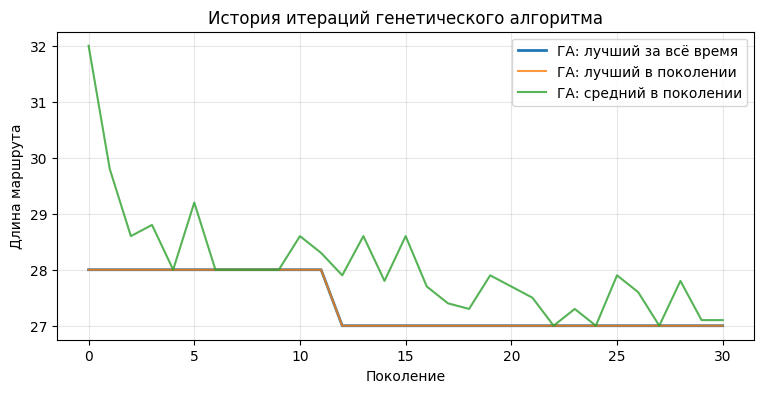

In [107]:
ga_best = ga_result["best_history"]
ga_iter_best = ga_result["iter_best_history"]
ga_iter_avg = ga_result["iter_avg_history"]

print("Первые 10 поколений (best-so-far):")
for i, v in enumerate(ga_best[:10]):
    print(f"{i:3d}: {v}")

print("\nПоследние 10 поколений (best-so-far):")
start = max(0, len(ga_best) - 10)
for i in range(start, len(ga_best)):
    print(f"{i:3d}: {ga_best[i]}")

plt.figure(figsize=(9, 4))
plt.plot(ga_best, label="ГА: лучший за всё время", linewidth=2)
plt.plot(ga_iter_best, label="ГА: лучший в поколении", alpha=0.8)
plt.plot(ga_iter_avg, label="ГА: средний в поколении", alpha=0.8)
plt.xlabel("Поколение")
plt.ylabel("Длина маршрута")
plt.title("История итераций генетического алгоритма")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Блок 1.7. Вывод по задаче 1

**Минимальная длина маршрута коммивояжёра: 27.**


## Задание 2. Кратчайший путь `A -> G` (алгоритм муравьиной колонии)

### Блок 2.1. Исходный граф

**Подпись:** рёбра и веса для варианта.


In [108]:
GRAPH = {
    "A": {"B": 4, "C": 14, "E": 4},
    "B": {"A": 4, "G": 32},
    "C": {"A": 14},
    "D": {"E": 7, "F": 6, "G": 18},
    "E": {"A": 4, "D": 7},
    "F": {"D": 6, "G": 6},
    "G": {"B": 32, "D": 18, "F": 6},
}

print("Список рёбер:")
seen = set()
for u in GRAPH:
    for v, w in GRAPH[u].items():
        edge = tuple(sorted((u, v)))
        if edge not in seen:
            print(f"{edge[0]}-{edge[1]} = {w}")
            seen.add(edge)


Список рёбер:
A-B = 4
A-C = 14
A-E = 4
B-G = 32
D-E = 7
D-F = 6
D-G = 18
F-G = 6


### Блок 2.2. Вспомогательная проверка (Дейкстра)

**Подпись:** контроль корректности результата ACO.


In [109]:
def path_length(path):
    return sum(GRAPH[path[i]][path[i + 1]] for i in range(len(path) - 1))


def dijkstra(start, goal):
    dist = {node: math.inf for node in GRAPH}
    prev = {node: None for node in GRAPH}
    dist[start] = 0
    unvisited = set(GRAPH)

    while unvisited:
        u = min(unvisited, key=lambda x: dist[x])
        unvisited.remove(u)

        if u == goal or dist[u] == math.inf:
            break

        for v, w in GRAPH[u].items():
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()

    return path, dist[goal]


### Блок 2.3. Реализация ACO

**Подпись:** вероятностный выбор рёбер, испарение и усиление феромона.


In [110]:
def choose_next(current, visited, pheromone, alpha, beta):
    neighbors = [n for n in GRAPH[current] if n not in visited]
    if not neighbors:
        return None

    scores = []
    for n in neighbors:
        tau = pheromone[(current, n)] ** alpha
        eta = (1.0 / GRAPH[current][n]) ** beta
        scores.append(tau * eta)

    total = sum(scores)
    r = random.random() * total
    acc = 0.0
    for n, s in zip(neighbors, scores):
        acc += s
        if acc >= r:
            return n
    return neighbors[-1]


def run_aco(
    start="A",
    goal="G",
    ants=60,
    iterations=120,
    alpha=1.0,
    beta=2.5,
    rho=0.25,
    q=100.0,
    seed=42,
):
    random.seed(seed)

    pheromone = defaultdict(lambda: 1.0)
    for u in GRAPH:
        for v in GRAPH[u]:
            pheromone[(u, v)] = 1.0

    best_path = None
    best_len = math.inf

    best_history = []
    iter_best_history = []
    iter_avg_history = []
    successful_ants_history = []

    for _ in range(iterations):
        paths = []

        for _ant in range(ants):
            current = start
            visited = {start}
            path = [start]

            while current != goal:
                nxt = choose_next(current, visited, pheromone, alpha, beta)
                if nxt is None:
                    path = None
                    break

                path.append(nxt)
                visited.add(nxt)
                current = nxt

            if path is None:
                continue

            length = path_length(path)
            paths.append((path, length))

            if length < best_len:
                best_len = length
                best_path = path

        for edge in list(pheromone.keys()):
            pheromone[edge] *= (1.0 - rho)
            if pheromone[edge] < 1e-8:
                pheromone[edge] = 1e-8

        for path, length in paths:
            delta = q / length
            for i in range(len(path) - 1):
                u, v = path[i], path[i + 1]
                pheromone[(u, v)] += delta
                pheromone[(v, u)] += delta

        if paths:
            iter_best = min(length for _, length in paths)
            iter_avg = sum(length for _, length in paths) / len(paths)
        else:
            iter_best = math.inf
            iter_avg = math.inf

        iter_best_history.append(iter_best)
        iter_avg_history.append(iter_avg)
        best_history.append(best_len)
        successful_ants_history.append(len(paths))

    return {
        "best_path": best_path,
        "best_length": best_len,
        "best_history": best_history,
        "iter_best_history": iter_best_history,
        "iter_avg_history": iter_avg_history,
        "successful_ants_history": successful_ants_history,
    }


### Блок 2.4. Запуск ACO и ручная проверка кандидатов

**Подпись:** вычисление лучшего пути и проверка ключевых маршрутов.


In [111]:
d_path, d_len = dijkstra("A", "G")
aco_result = run_aco(
    seed=SEED,
    ants=10,
    iterations=50,
    alpha=1,        # влияние феромона
    rho=0.5,        # испарение феромона
    beta=2.5,       # влияние привлекательности коротких рёбер
    q=10            # коэф. усиления феромона на пути
)

aco_path = aco_result["best_path"]
aco_len = aco_result["best_length"]

print("Дейкстра:", " -> ".join(d_path), ", длина =", d_len)
print("ACO     :", " -> ".join(aco_path), ", длина =", aco_len)

candidates = [
    ["A", "B", "G"],
    ["A", "E", "D", "G"],
    ["A", "E", "D", "F", "G"],
]

print("\nПроверка кандидатов:")
for c in candidates:
    print(" -> ".join(c), "=", path_length(c))


Дейкстра: A -> E -> D -> F -> G , длина = 23
ACO     : A -> E -> D -> F -> G , длина = 23

Проверка кандидатов:
A -> B -> G = 36
A -> E -> D -> G = 29
A -> E -> D -> F -> G = 23


### Блок 2.5. История итераций ACO

**Подпись:** динамика лучшего найденного пути и лучшего значения по текущей итерации.


Первые 10 итераций ACO (best-so-far):
  0: 23
  1: 23
  2: 23
  3: 23
  4: 23
  5: 23
  6: 23
  7: 23
  8: 23
  9: 23

Последние 10 итераций ACO (best-so-far):
 40: 23
 41: 23
 42: 23
 43: 23
 44: 23
 45: 23
 46: 23
 47: 23
 48: 23
 49: 23


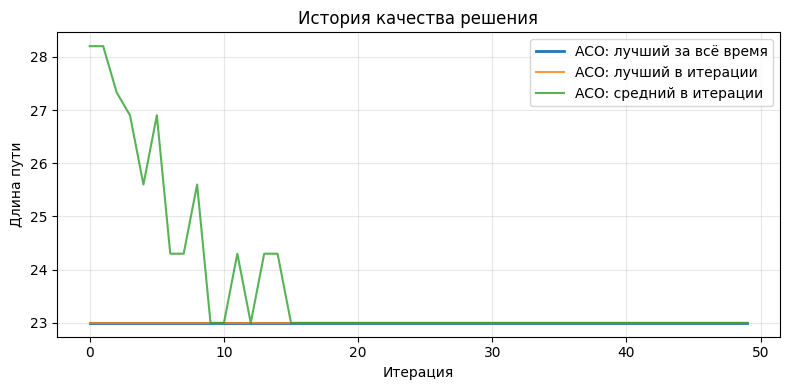

In [112]:
aco_best = aco_result["best_history"]
aco_iter_best = aco_result["iter_best_history"]
aco_iter_avg = aco_result["iter_avg_history"]
aco_success = aco_result["successful_ants_history"]

print("Первые 10 итераций ACO (best-so-far):")
for i, v in enumerate(aco_best[:10]):
    print(f"{i:3d}: {v}")

print("\nПоследние 10 итераций ACO (best-so-far):")
start = max(0, len(aco_best) - 10)
for i in range(start, len(aco_best)):
    print(f"{i:3d}: {aco_best[i]}")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.plot(aco_best, label="ACO: лучший за всё время", linewidth=2)
ax.plot(aco_iter_best, label="ACO: лучший в итерации", alpha=0.8)
ax.plot(aco_iter_avg, label="ACO: средний в итерации", alpha=0.8)
ax.set_xlabel("Итерация")
ax.set_ylabel("Длина пути")
ax.set_title("История качества решения")
ax.grid(True, alpha=0.3)
ax.legend()

# ax[1].plot(aco_success, color="tab:green")
# ax[1].set_xlabel("Итерация")
# ax[1].set_ylabel("Число успешных муравьёв")
# ax[1].set_title("Сколько муравьёв дошли до цели")
# ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Блок 2.7. Вывод по задаче 2

**Кратчайший путь: `A -> E -> D -> F -> G`, длина = 23.**


## Финальные выводы

1. Для задачи коммивояжёра получена минимальная длина маршрута **27**.
2. Для задачи `A -> G` методом муравьиной колонии получен путь **`A -> E -> D -> F -> G`** длиной **23**.
3. Для обоих алгоритмов добавлен просмотр **истории итераций** (численно и на графиках).
